<a href="https://colab.research.google.com/github/SuyogPatgave/Python_Codes-Projects/blob/main/CRM_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Import and View


Importing library packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
import statistics

Data Import

In [ ]:
acc= pd.read_csv('/content/accounts.csv')
data_dic = pd.read_csv('/content/data_dictionary.csv')
prdts = pd.read_csv('/content/products.csv')
sales_pipe = pd.read_csv('/content/sales_pipeline.csv')
sales_team = pd.read_csv('/content/sales_teams.csv')

In [ ]:
pd.set_option('display.width', 300)
pd.set_option('display.max_columns', None)

Consolidating all datasets (assigning names for referential convenience) in one list

In [ ]:
datasets = [('accounts', acc), ('data dictionary', data_dic), ('products', prdts), ('sales pipeline', sales_pipe), ('sales team', sales_team)]

Data Visibility

In [ ]:
for name, dataset in datasets:
  print(f"\n\n\n{name.title()}:")
  print(dataset.head(10))
  print(f"--Dimensions: {dataset.shape}")




Accounts:
            account         sector  year_established  revenue  employees office_location     subsidiary_of
0  Acme Corporation      technolgy              1996  1100.04       2822   United States               NaN
1        Betasoloin        medical              1999   251.41        495   United States               NaN
2          Betatech        medical              1986   647.18       1185           Kenya               NaN
3        Bioholding        medical              2012   587.34       1356      Philipines               NaN
4           Bioplex        medical              1991   326.82       1016   United States               NaN
5          Blackzim         retail              2009   497.11       1588   United States               NaN
6     Bluth Company      technolgy              1993  1242.32       3027   United States  Acme Corporation
7        Bubba Gump       software              2002   987.39       2253   United States               NaN
8           Cancity     

Data Description

In [ ]:
  for name, dataset in datasets:
    print(f"\n\n\n{name.title()}:")
    print(dataset.describe())




Accounts:
       year_established       revenue     employees
count         85.000000     85.000000     85.000000
mean        1996.105882   1994.632941   4660.823529
std            8.865427   2169.491436   5715.601198
min         1979.000000      4.540000      9.000000
25%         1989.000000    497.110000   1179.000000
50%         1996.000000   1223.720000   2769.000000
75%         2002.000000   2741.370000   5595.000000
max         2017.000000  11698.030000  34288.000000



Data Dictionary:
                 Table    Field   Description
count               21       21            21
unique               4       18            19
top     sales_pipeline  account  Company name
freq                 8        2             2



Products:
        sales_price
count      7.000000
mean    6023.571429
std     9388.428070
min       55.000000
25%      823.000000
50%     3393.000000
75%     5151.500000
max    26768.000000



Sales Pipeline:
        close_value
count   6711.000000
mean    1490.9155

# Data Pre-Processing

######At this stage of the project, I'm just cleaning the information! It begins with inspection of any given dataset and then taking relevant actions to counter the redundant information or formatting the available information to uniformally process the data in the further analytical pipeline.

Account Table

In [ ]:
acc

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,NaN
1,Betasoloin,medical,1999,251.41,495,United States,NaN
2,Betatech,medical,1986,647.18,1185,Kenya,NaN
3,Bioholding,medical,2012,587.34,1356,Philipines,NaN
4,Bioplex,medical,1991,326.82,1016,United States,NaN
...,...,...,...,...,...,...,...
80,Zathunicon,retail,2010,71.12,144,United States,NaN
81,Zencorporation,technolgy,2011,40.79,142,China,NaN
82,Zoomit,entertainment,1992,324.19,978,United States,NaN
83,Zotware,software,1979,4478.47,13809,United States,NaN


In [ ]:
# Focusing on "Categorical variables", grouping them together to make a list
acc_cols = acc[['account', 'sector', 'office_location', 'subsidiary_of']]

In [ ]:
# Creating a function to provide us with: Name of the column from the table/dataframe
# Frequency of each categorical value
# Total number of null values
# Dimension of the dataset
# The data type of each column
def short_summary(df):
  for columns in df:
      print(f"\n\n\nColumn Name: {df[columns].name}")
      print(df[columns].value_counts())
      print(f"Number of Null values: {df[columns].isnull().sum()}")
      print(f"Dimensions--{df.shape}")
      print(f"Data type: {df[columns].dtype}")

In [ ]:
'''for columns in acc_cols:
  print(f"\n\n\nColumn Name: {acc_cols[columns].name}")
  print(f"Number of Null values: {acc_cols[columns].isnull().sum()}")
  print(acc_cols[columns].value_counts())'''
short_summary(acc_cols)
# Why are we doing this?!
# It helps us understand if there're any error in the categorical values, such as spelling/wording error.
# Also it helps us understand the frequency of each nique value occuring in the dataset
# Example: Is there a "retail" sector and a "Retail" sector




Column Name: account
account
Acme Corporation    1
Betasoloin          1
Betatech            1
Bioholding          1
Bioplex             1
                   ..
Zathunicon          1
Zencorporation      1
Zoomit              1
Zotware             1
Zumgoity            1
Name: count, Length: 85, dtype: int64
Number of Null values: 0
Dimensions--(85, 4)
Data type: object



Column Name: sector
sector
retail                17
technolgy             12
medical               12
marketing              8
finance                8
software               7
entertainment          6
telecommunications     6
services               5
employment             4
Name: count, dtype: int64
Number of Null values: 0
Dimensions--(85, 4)
Data type: object



Column Name: office_location
office_location
United States    71
Kenya             1
Philipines        1
Japan             1
Italy             1
Norway            1
Korea             1
Jordan            1
Brazil            1
Germany           1
Panama  

In [ ]:
# Since not all the accounts are subsidiary of any parent company, we'll be assigning
# a label value "Not a subsidiary" to all the null values in the column "subsidiary of"
# This may later help in EDA/classification of the data!
acc.subsidiary_of =  acc.subsidiary_of.fillna('Not a Subsidiary')
acc

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,Not a Subsidiary
1,Betasoloin,medical,1999,251.41,495,United States,Not a Subsidiary
2,Betatech,medical,1986,647.18,1185,Kenya,Not a Subsidiary
3,Bioholding,medical,2012,587.34,1356,Philipines,Not a Subsidiary
4,Bioplex,medical,1991,326.82,1016,United States,Not a Subsidiary
...,...,...,...,...,...,...,...
80,Zathunicon,retail,2010,71.12,144,United States,Not a Subsidiary
81,Zencorporation,technolgy,2011,40.79,142,China,Not a Subsidiary
82,Zoomit,entertainment,1992,324.19,978,United States,Not a Subsidiary
83,Zotware,software,1979,4478.47,13809,United States,Not a Subsidiary


In [ ]:
acc['sector']= acc['sector'].astype('category')

In [ ]:
#Viewing Table
acc

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,Not a Subsidiary
1,Betasoloin,medical,1999,251.41,495,United States,Not a Subsidiary
2,Betatech,medical,1986,647.18,1185,Kenya,Not a Subsidiary
3,Bioholding,medical,2012,587.34,1356,Philipines,Not a Subsidiary
4,Bioplex,medical,1991,326.82,1016,United States,Not a Subsidiary
...,...,...,...,...,...,...,...
80,Zathunicon,retail,2010,71.12,144,United States,Not a Subsidiary
81,Zencorporation,technolgy,2011,40.79,142,China,Not a Subsidiary
82,Zoomit,entertainment,1992,324.19,978,United States,Not a Subsidiary
83,Zotware,software,1979,4478.47,13809,United States,Not a Subsidiary


Products Table

In [ ]:
prdts
#Seems pretty simple and straightforward table, more like a reference table to
# simple information on the products. Moving on....!

,product,series,sales_price
0,GTX Basic,GTX,550
1,GTX Pro,GTX,4821
2,MG Special,MG,55
3,MG Advanced,MG,3393
4,GTX Plus Pro,GTX,5482
5,GTX Plus Basic,GTX,1096
6,GTK 500,GTK,26768


Sales Pipeline Table

In [ ]:
# This table is of high significance. I call this as an action table which pretty much closely aligns with the fact table in start/snowflake configuration.
sales_pipe

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0
...,...,...,...,...,...,...,...,...
8795,9MIWFW5J,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaN,NaN
8796,6SLKZ8FI,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaN,NaN
8797,LIB4KUZJ,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaN,NaN
8798,18IUIUK0,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaN,NaN,NaN


In [ ]:
sales_pipe_cols = sales_pipe[['sales_agent', 'product', 'account', 'deal_stage']]

In [ ]:
'''for values in sales_pipe_cols:
  print(f"\n\n\n{values}")
  print(f"Number of Null values: {sales_pipe_cols[values].isnull().sum()}")
  print(sales_pipe_cols[values].value_counts())'''

short_summary(sales_pipe_cols)




Column Name: sales_agent
sales_agent
Darcel Schlecht       747
Vicki Laflamme        451
Anna Snelling         448
Kary Hendrixson       438
Kami Bicknell         362
Versie Hillebrand     361
Zane Levy             349
Cassey Cress          346
Jonathan Berthelot    345
Gladys Colclough      317
Lajuana Vencill       311
Corliss Cosme         310
Markita Hansen        306
Maureen Marcano       285
Marty Freudenburg     281
Donn Cantrell         275
James Ascencio        267
Violet Mclelland      261
Moses Frase           260
Daniell Hammack       259
Niesha Huffines       239
Reed Clapper          237
Boris Faz             210
Cecily Lampkin        203
Hayden Neloms         202
Elease Gluck          177
Rosalina Dieter       160
Rosie Papadopoulos    160
Garret Kinder         123
Wilburn Farren        110
Name: count, dtype: int64
Number of Null values: 0
Dimensions--(8800, 4)
Data type: object



Column Name: product
product
GTX Basic         1866
MG Special        1651
GTXPro     

In [ ]:
#Converting date values to date data type, converting from string/object

sales_pipe['close_date'] = pd.to_datetime(sales_pipe['close_date'])
sales_pipe['engage_date'] = pd.to_datetime(sales_pipe['engage_date'])


#Converting Deal stage to factor/category

sales_pipe['deal_satge'] = sales_pipe['deal_stage'].astype('category')

In [ ]:
sales_pipe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   opportunity_id  8800 non-null   object        
 1   sales_agent     8800 non-null   object        
 2   product         8800 non-null   object        
 3   account         7375 non-null   object        
 4   deal_stage      8800 non-null   object        
 5   engage_date     8300 non-null   datetime64[ns]
 6   close_date      6711 non-null   datetime64[ns]
 7   close_value     6711 non-null   float64       
 8   deal_satge      8800 non-null   category      
dtypes: category(1), datetime64[ns](2), float64(1), object(5)
memory usage: 558.9+ KB


In [ ]:
# for view
sales_pipe

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,Won
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,Won
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,Won
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,Won
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,Won
...,...,...,...,...,...,...,...,...,...
8795,9MIWFW5J,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8796,6SLKZ8FI,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8797,LIB4KUZJ,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8798,18IUIUK0,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting


Null/NaN values in Sales Pipe

In [ ]:
# Inspecting records where account is null/NaN in the dataset
# This will give us an idea about the null values and what the data effectively stands for/conveys the information

sales_pipe_null_acc =  sales_pipe[sales_pipe['account'].isnull()]
print(sales_pipe_null_acc)
print(f"Records by deal stages:- \n {sales_pipe_null_acc['deal_stage'].value_counts()}") # This will provide us with the unique values in the column "Deal_Stage" and their frequency
print(sales_pipe_null_acc.shape) #total number of records for null accounts dataset

# deduction:
# null values in account column represent two distinctiv deal stages: Engaging
# and prospecting


     opportunity_id        sales_agent         product account   deal_stage engage_date close_date  close_value   deal_satge
9          HAXMC4IX     James Ascencio     MG Advanced     NaN     Engaging  2016-11-03        NaT          NaN     Engaging
42         EG7OFLFR      Kami Bicknell       GTX Basic     NaN     Engaging  2016-11-14        NaT          NaN     Engaging
44         OLVI7L8M       Cassey Cress          GTXPro     NaN     Engaging  2016-11-16        NaT          NaN     Engaging
56         F5U1ACDD      Kami Bicknell  GTX Plus Basic     NaN     Engaging  2016-11-19        NaT          NaN     Engaging
60         ZZY4516R      Hayden Neloms     MG Advanced     NaN     Engaging  2016-11-20        NaT          NaN     Engaging
...             ...                ...             ...     ...          ...         ...        ...          ...          ...
8795       9MIWFW5J  Versie Hillebrand     MG Advanced     NaN  Prospecting         NaT        NaT          NaN  Prospecting


Dividing sales pipe table in 'Won + Lost', 'Engaging', and 'Prospecting'

In [ ]:
# Data Subset for "WON" and "LOST"

sales_pipe_labelled = sales_pipe[(sales_pipe['deal_stage'] == 'Won') | (sales_pipe['deal_stage'] == 'Lost')]
print(sales_pipe_labelled)

#print(sales_pipe_labelled['deal_stage'].value_counts())

short_summary(sales_pipe_labelled)

# You may notice that the entire data subset (WON + LOST) has no null values.

     opportunity_id       sales_agent         product        account deal_stage engage_date close_date  close_value deal_satge
0          1C1I7A6R       Moses Frase  GTX Plus Basic        Cancity        Won  2016-10-20 2017-03-01       1054.0        Won
1          Z063OYW0   Darcel Schlecht          GTXPro          Isdom        Won  2016-10-25 2017-03-11       4514.0        Won
2          EC4QE1BX   Darcel Schlecht      MG Special        Cancity        Won  2016-10-25 2017-03-07         50.0        Won
3          MV1LWRNH       Moses Frase       GTX Basic        Codehow        Won  2016-10-25 2017-03-09        588.0        Won
4          PE84CX4O         Zane Levy       GTX Basic         Hatfan        Won  2016-10-25 2017-03-02        517.0        Won
...             ...               ...             ...            ...        ...         ...        ...          ...        ...
8295       2EBLR9N8   Lajuana Vencill       GTX Basic        Conecom        Won  2017-12-24 2017-12-26        6

In [ ]:
#Viewing Labelled Data
sales_pipe_labelled

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,Won
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,Won
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,Won
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,Won
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,Won
...,...,...,...,...,...,...,...,...,...
8295,2EBLR9N8,Lajuana Vencill,GTX Basic,Conecom,Won,2017-12-24,2017-12-26,622.0,Won
8296,VDGA4KXA,Violet Mclelland,GTX Plus Basic,Bluth Company,Won,2017-12-24,2017-12-30,1093.0,Won
8297,6WCNNK5J,Maureen Marcano,GTXPro,Hottechi,Won,2017-12-26,2017-12-29,4433.0,Won
8298,YJTQSZ9D,Gladys Colclough,GTX Plus Basic,Inity,Won,2017-12-27,2017-12-30,1052.0,Won


In [ ]:
# Data Subset for Engaging

sales_pipe_engage = sales_pipe[(sales_pipe["deal_stage"])=="Engaging"]
print(sales_pipe_engage)

short_summary(sales_pipe_engage)
print(f"Total engaging records with an account: {sum(sales_pipe_engage['account'].value_counts())}")

     opportunity_id      sales_agent         product    account deal_stage engage_date close_date  close_value deal_satge
9          HAXMC4IX   James Ascencio     MG Advanced        NaN   Engaging  2016-11-03        NaT          NaN   Engaging
25         UP409DSB  Maureen Marcano     MG Advanced  Ganjaflex   Engaging  2016-11-10        NaT          NaN   Engaging
42         EG7OFLFR    Kami Bicknell       GTX Basic        NaN   Engaging  2016-11-14        NaT          NaN   Engaging
44         OLVI7L8M     Cassey Cress          GTXPro        NaN   Engaging  2016-11-16        NaT          NaN   Engaging
56         F5U1ACDD    Kami Bicknell  GTX Plus Basic        NaN   Engaging  2016-11-19        NaT          NaN   Engaging
...             ...              ...             ...        ...        ...         ...        ...          ...        ...
8277       NGTVHTFH        Boris Faz          GTXPro        NaN   Engaging  2017-12-19        NaT          NaN   Engaging
8283       HB740BLB    H

In [ ]:
#Viewing data
sales_pipe_engage

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge
9,HAXMC4IX,James Ascencio,MG Advanced,NaN,Engaging,2016-11-03,NaT,NaN,Engaging
25,UP409DSB,Maureen Marcano,MG Advanced,Ganjaflex,Engaging,2016-11-10,NaT,NaN,Engaging
42,EG7OFLFR,Kami Bicknell,GTX Basic,NaN,Engaging,2016-11-14,NaT,NaN,Engaging
44,OLVI7L8M,Cassey Cress,GTXPro,NaN,Engaging,2016-11-16,NaT,NaN,Engaging
56,F5U1ACDD,Kami Bicknell,GTX Plus Basic,NaN,Engaging,2016-11-19,NaT,NaN,Engaging
...,...,...,...,...,...,...,...,...,...
8277,NGTVHTFH,Boris Faz,GTXPro,NaN,Engaging,2017-12-19,NaT,NaN,Engaging
8283,HB740BLB,Hayden Neloms,MG Special,Silis,Engaging,2017-12-20,NaT,NaN,Engaging
8285,HCQK8NQ8,Wilburn Farren,GTX Plus Basic,NaN,Engaging,2017-12-20,NaT,NaN,Engaging
8286,RDHTQLNI,Cassey Cress,GTX Plus Pro,NaN,Engaging,2017-12-21,NaT,NaN,Engaging


In [ ]:
#Data Subset for Prospecting

## Just like we preprocessed and created a data subset for "Engaging"

sales_pipe_prospect = sales_pipe[(sales_pipe["deal_stage"])=="Prospecting"]
print(sales_pipe_prospect)

short_summary(sales_pipe_prospect)
print(f"Total prospecting records with an account: {sum(sales_pipe_prospect['account'].value_counts())}")

     opportunity_id        sales_agent      product     account   deal_stage engage_date close_date  close_value   deal_satge
8300       6CWZFOHJ      Anna Snelling    GTX Basic  Green-Plus  Prospecting         NaT        NaT          NaN  Prospecting
8301       3LCLVRVV      Anna Snelling    GTX Basic         NaN  Prospecting         NaT        NaT          NaN  Prospecting
8302       YIU1B39V      Anna Snelling    GTX Basic         NaN  Prospecting         NaT        NaT          NaN  Prospecting
8303       8E0VRCLW      Anna Snelling    GTX Basic         NaN  Prospecting         NaT        NaT          NaN  Prospecting
8304       G99CS23F      Anna Snelling    GTX Basic         NaN  Prospecting         NaT        NaT          NaN  Prospecting
...             ...                ...          ...         ...          ...         ...        ...          ...          ...
8795       9MIWFW5J  Versie Hillebrand  MG Advanced         NaN  Prospecting         NaT        NaT          NaN  Pros

In [ ]:
#viewing data
sales_pipe_prospect

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge
8300,6CWZFOHJ,Anna Snelling,GTX Basic,Green-Plus,Prospecting,NaT,NaT,NaN,Prospecting
8301,3LCLVRVV,Anna Snelling,GTX Basic,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8302,YIU1B39V,Anna Snelling,GTX Basic,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8303,8E0VRCLW,Anna Snelling,GTX Basic,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8304,G99CS23F,Anna Snelling,GTX Basic,NaN,Prospecting,NaT,NaT,NaN,Prospecting
...,...,...,...,...,...,...,...,...,...
8795,9MIWFW5J,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8796,6SLKZ8FI,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8797,LIB4KUZJ,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8798,18IUIUK0,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting


Sales Team Table

In [ ]:
# Pretty simple and straightforward table/dataset
# Much like a dimension table in star/snowflake configuration, here we have
# primary information about the associates/sales agents, managers, and work location

print(sales_team)
short_summary(sales_team)

           sales_agent           manager regional_office
0        Anna Snelling  Dustin Brinkmann         Central
1       Cecily Lampkin  Dustin Brinkmann         Central
2    Versie Hillebrand  Dustin Brinkmann         Central
3      Lajuana Vencill  Dustin Brinkmann         Central
4          Moses Frase  Dustin Brinkmann         Central
5   Jonathan Berthelot     Melvin Marxen         Central
6    Marty Freudenburg     Melvin Marxen         Central
7     Gladys Colclough     Melvin Marxen         Central
8      Niesha Huffines     Melvin Marxen         Central
9      Darcel Schlecht     Melvin Marxen         Central
10       Mei-Mei Johns     Melvin Marxen         Central
11    Violet Mclelland        Cara Losch            East
12       Corliss Cosme        Cara Losch            East
13  Rosie Papadopoulos        Cara Losch            East
14       Garret Kinder        Cara Losch            East
15      Wilburn Farren        Cara Losch            East
16  Elizabeth Anderson        C

Datasets for further Data Formatting

In [ ]:
datasets2 = [('accounts', acc), ('products', prdts),
        ('sales_pipeline', sales_pipe), ('sales team', sales_team),
        ('won_lost', sales_pipe_labelled), ('prospect', sales_pipe_prospect),
              ('engaging', sales_pipe_engage)]

In [ ]:
for name, dataset in datasets2:
  print(f"\n\n\n*** Dataset: {name.title()} ***")
  print(f"*** Dimensions: {dataset.shape} ***")
  print(f"Info: {dataset.info()}")
  print(f"\n\n\nNull Values in {dataset.isnull().sum()}")
  print(f"\nData view {dataset.head(10)}")




*** Dataset: Accounts ***
*** Dimensions: (85, 7) ***
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   account           85 non-null     object  
 1   sector            85 non-null     category
 2   year_established  85 non-null     int64   
 3   revenue           85 non-null     float64 
 4   employees         85 non-null     int64   
 5   office_location   85 non-null     object  
 6   subsidiary_of     85 non-null     object  
dtypes: category(1), float64(1), int64(2), object(3)
memory usage: 4.6+ KB
Info: None



Null Values in account             0
sector              0
year_established    0
revenue             0
employees           0
office_location     0
subsidiary_of       0
dtype: int64

Data view             account         sector  year_established  revenue  employees office_location     subsidiary_of
0  Acme Corporation 

In [ ]:
#Checking duplicates in each dataframe

def dup_check (df):
  for name, dataset in df:
    print(f"\n{name.title()}:")
    print(f"{dataset.duplicated().sum()}")


dup_check(datasets2)


Accounts:
0

Products:
0

Sales_Pipeline:
0

Sales Team:
0

Won_Lost:
0

Prospect:
0

Engaging:
0


# Note!


- You may skip the EDA part of this project. But why?!
- Since most of the EDA (Exploratory Data Analysis) revolves around creating/developing visuals and informative data tables, I'll be using BI tools such as Power BI/Tableau (mostly Tableau!) to gain insights.

Additionally, feel free to inspect my codes! In the following sections within EDA, I have used multiple functions such as merge, groupby, sort, etc.

# EDA!

## Accounts

In [ ]:
pd.set_option('display.width', 700)
pd.set_option('display.max_columns', None)

In [ ]:
acc.head(10)

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,Not a Subsidiary
1,Betasoloin,medical,1999,251.41,495,United States,Not a Subsidiary
2,Betatech,medical,1986,647.18,1185,Kenya,Not a Subsidiary
3,Bioholding,medical,2012,587.34,1356,Philipines,Not a Subsidiary
4,Bioplex,medical,1991,326.82,1016,United States,Not a Subsidiary
5,Blackzim,retail,2009,497.11,1588,United States,Not a Subsidiary
6,Bluth Company,technolgy,1993,1242.32,3027,United States,Acme Corporation
7,Bubba Gump,software,2002,987.39,2253,United States,Not a Subsidiary
8,Cancity,retail,2001,718.62,2448,United States,Not a Subsidiary
9,Cheers,entertainment,1993,4269.90,6472,United States,Massive Dynamic


In [ ]:
'''latest_year = acc['year_established'].max()
last_10 = latest_year - 10
last_5 = latest_year - 5

revenue_10 = (
    acc[acc['year_established'] >= last_10]
    .groupby('sector', as_index=False)['revenue'].sum()
    .sort_values(by='revenue', ascending=False)
)

revenue_5 = (
    acc[acc['year_established'] >= last_5]
    .groupby('sector', as_index=False)['revenue'].sum()
    .sort_values(by='revenue', ascending=False)
)

print("Revenue by sector (companies founded in last 10 years):")
print(revenue_10)

print("\nRevenue by sector (companies founded in last 5 years):")
print(revenue_5)'''


'latest_year = acc[\'year_established\'].max()\nlast_10 = latest_year - 10\nlast_5 = latest_year - 5\n\nrevenue_10 = (\n    acc[acc[\'year_established\'] >= last_10]\n    .groupby(\'sector\', as_index=False)[\'revenue\'].sum()\n    .sort_values(by=\'revenue\', ascending=False)\n)\n\nrevenue_5 = (\n    acc[acc[\'year_established\'] >= last_5]\n    .groupby(\'sector\', as_index=False)[\'revenue\'].sum()\n    .sort_values(by=\'revenue\', ascending=False)\n)\n\nprint("Revenue by sector (companies founded in last 10 years):")\nprint(revenue_10)\n\nprint("\nRevenue by sector (companies founded in last 5 years):")\nprint(revenue_5)'

In [ ]:
### SKIP!!!!
#Which sector provide the most revenue and in which year were they established, the top 10?
'''sec_rev_l10 = (acc.groupby(['year_established','sector'], as_index=False)['revenue'].sum().sort_values(by='revenue', ascending=False))
sec_rev_l10.head(10)'''

"sec_rev_l10 = (acc.groupby(['year_established','sector'], as_index=False)['revenue'].sum().sort_values(by='revenue', ascending=False))\nsec_rev_l10.head(10)"

In [ ]:
## SKIP!!
# for every year, who (which sector) was the top contributor to the revenue and how much the revenue was
'''
result1 = acc.groupby(['year_established', 'sector'], as_index= False)['revenue'].sum()
result2 = result1.sort_values(['year_established', 'revenue'], ascending=[False, False])
result3 = result2.groupby('year_established').head(1)
result3
# Total revenue per year
result4 = acc.groupby('year_established')['revenue'].sum()
#merging with result 3

result5 = pd.merge(result3, result4, on='year_established')
result5 = result5.rename(columns = {'revenue_y': 'total_revenue', 'revenue_x':'sector_revenue'})
result5['share_of_sector'] = result5['sector_revenue']/result5['total_revenue']
result5['share_of_sector'] = result5['share_of_sector'].round(2)
result5
# This shows us which market sector was the top contributor to the total revenue
# for each year, and the share of revenue
'''

"\nresult1 = acc.groupby(['year_established', 'sector'], as_index= False)['revenue'].sum()\nresult2 = result1.sort_values(['year_established', 'revenue'], ascending=[False, False])\nresult3 = result2.groupby('year_established').head(1)\nresult3\n# Total revenue per year\nresult4 = acc.groupby('year_established')['revenue'].sum()\n#merging with result 3\n\nresult5 = pd.merge(result3, result4, on='year_established')\nresult5 = result5.rename(columns = {'revenue_y': 'total_revenue', 'revenue_x':'sector_revenue'})\nresult5['share_of_sector'] = result5['sector_revenue']/result5['total_revenue']\nresult5['share_of_sector'] = result5['share_of_sector'].round(2)\nresult5\n# This shows us which market sector was the top contributor to the total revenue\n# for each year, and the share of revenue\n"

    office_location              sector   revenue
147   United States            software  30950.45
145   United States              retail  19758.03
149   United States  telecommunications  16461.91
142   United States             finance  16233.34
144   United States             medical  15742.36
148   United States           technolgy  15406.97
141   United States       entertainment   9665.22
143   United States           marketing   9148.55
88            Korea           technolgy   8170.38
140   United States          employment   6104.64
55            Japan              retail   5158.71
146   United States            services   3526.38
63           Jordan           marketing   3027.46
108          Panama           technolgy   2938.67
5           Belgium              retail   1376.80
98           Norway           technolgy   1223.72
36          Germany            services   1012.72
123          Poland           marketing    894.37
45            Italy              retail    894.33


/tmp/ipython-input-878010849.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loc_sec_rev = (acc.groupby(['office_location', 'sector'], as_index=False)['revenue'].sum().sort_values(by='revenue', ascending=False))
/tmp/ipython-input-878010849.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.heatmap(loc_sec_rev.pivot_table(index='office_location', columns='sector', values='revenue'), annot=True, fmt='g', cmap='YlGnBu')


<Axes: xlabel='sector', ylabel='office_location'>

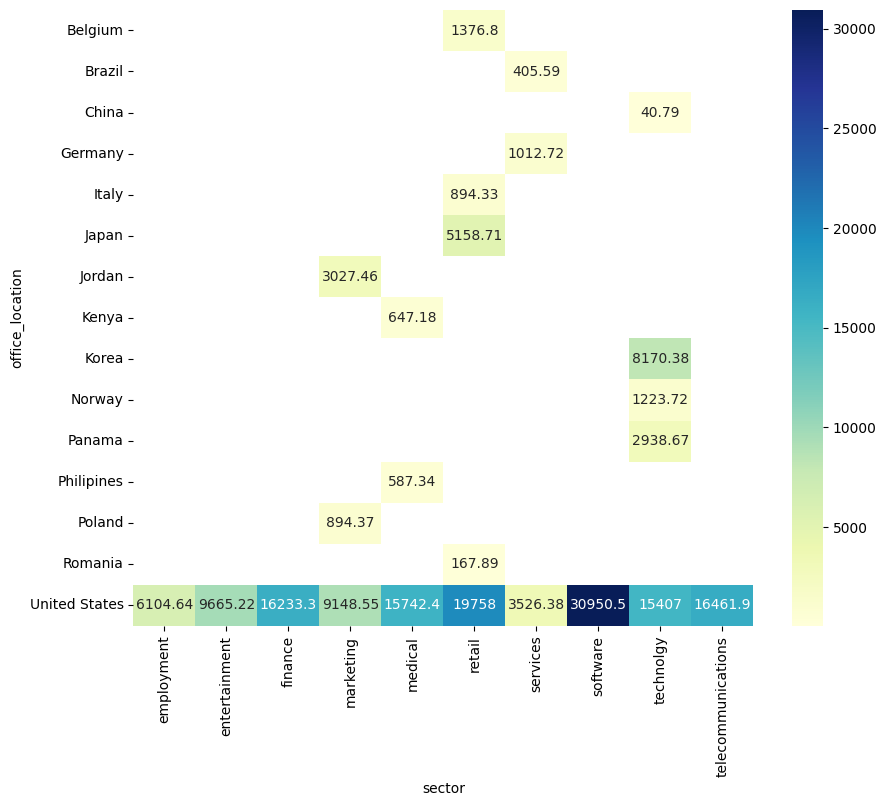

In [ ]:
# Total Revenue by Sectors for all listed Countries (Account Country of Origin)
## Exploring with market potential for sales

plt.figure(figsize=(10,8))
loc_sec_rev = (acc.groupby(['office_location', 'sector'], as_index=False)['revenue'].sum().sort_values(by='revenue', ascending=False))
loc_sec_rev = loc_sec_rev[loc_sec_rev['revenue']!= 0]
print(loc_sec_rev)
sns.heatmap(loc_sec_rev.pivot_table(index='office_location', columns='sector', values='revenue'), annot=True, fmt='g', cmap='YlGnBu')

/tmp/ipython-input-105089109.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acc_by_sec = acc.groupby('sector').size().sort_values(ascending=False).reset_index(name='total_accounts')





--**TOTAL NUMBER OF ACCOUNTS BY SECTOR**--
               sector  total_accounts
0              retail              17
1             medical              12
2           technolgy              12
3           marketing               8
4             finance               8
5            software               7
6  telecommunications               6
7       entertainment               6
8            services               5
9          employment               4




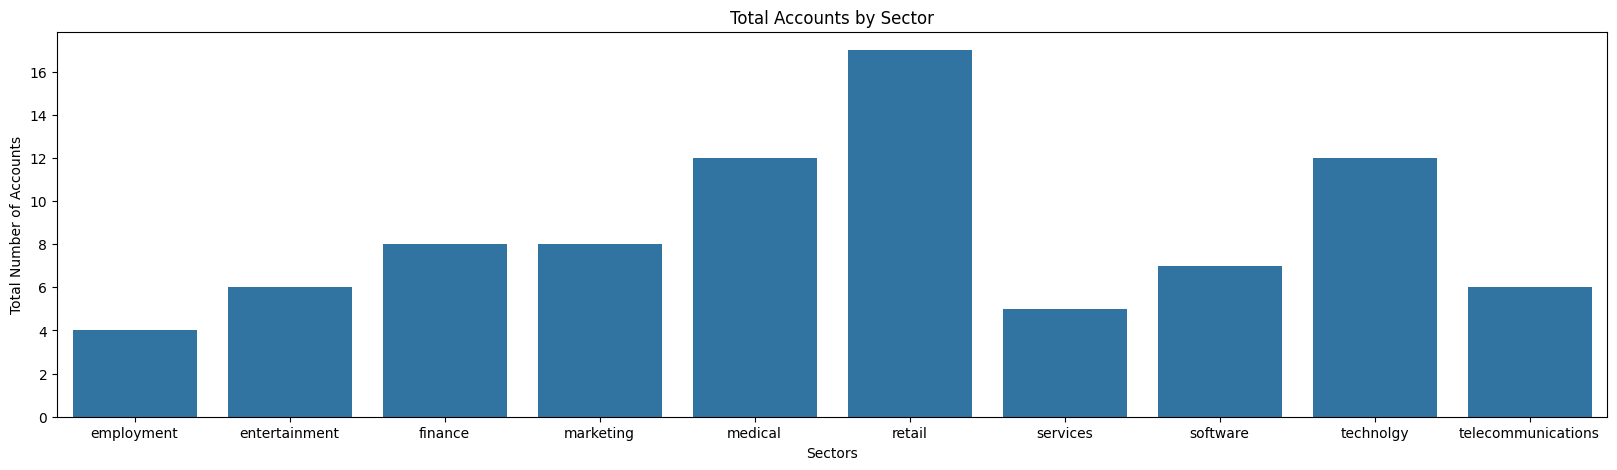

In [ ]:
#1.1 Total accounts by sectors
acc_by_sec = acc.groupby('sector').size().sort_values(ascending=False).reset_index(name='total_accounts')
#print(acc['account'].value_counts())
print(f"\n\n\n--**TOTAL NUMBER OF ACCOUNTS BY SECTOR**--\n{acc_by_sec}\n\n")
plt.figure(figsize=(20,5))
sns.barplot(x="sector", y="total_accounts", data=acc_by_sec)
plt.title('Total Accounts by Sector')
plt.xlabel('Sectors')
plt.ylabel('Total Number of Accounts')
plt.show()

In [ ]:
# Total Revenue for Tech sector (code trial)
acc_tech= acc[acc['sector']=="technolgy"]
round(acc_tech.revenue.sum(), 2)

np.float64(27780.53)

In [ ]:
#Average and Total Revenue by Sector
rev_by_sec = acc.groupby('sector').agg({'revenue': ['sum', 'mean']}).round(2).sort_values(by=('revenue', 'sum'), ascending=False)
rev_by_sec
rev_by_sec.columns = ['total_revenue', 'average_revenue']
rev_by_sec = rev_by_sec.reset_index()
rev_by_sec = rev_by_sec.sort_values(by='total_revenue', ascending=False)
rev_by_sec

/tmp/ipython-input-3896726251.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rev_by_sec = acc.groupby('sector').agg({'revenue': ['sum', 'mean']}).round(2).sort_values(by=('revenue', 'sum'), ascending=False)


,sector,total_revenue,average_revenue
0,software,30950.45,4421.49
1,technolgy,27780.53,2315.04
2,retail,27355.76,1609.16
3,medical,16976.88,1414.74
4,telecommunications,16461.91,2743.65
5,finance,16233.34,2029.17
6,marketing,13070.38,1633.80
7,entertainment,9665.22,1610.87
8,employment,6104.64,1526.16
9,services,4944.69,988.94


In [ ]:
# Total accounts by parent company
## Subsidiaries counted as +1 to the parent company
# Using merge function
accL = acc.copy()
print(f"\n\nLeft Table:\n{accL.head(10)}")
accR= acc.copy()
print(f"\n\nRight Table:\n{accR.head(10)}")
acc_main = accL.merge(accR, left_on='subsidiary_of', right_on='account', how='left')
print(f"\n\nMain Table:\n{acc_main.head(10)}")
'''#acc_main
#acc_main = acc.merge(acc, left_on='subsidiary_of', right_on='account', how='left')
#acc_main
#acc_main['main_acc'] = acc_main['subsidiary_of_y'].fillna(acc_main['account_x'])
#acc_main'''
acc_main['main_accn'] = acc_main['account_y'].fillna(acc_main['account_x'])
print(f"\n\nMain Table2:\n{acc_main.head(10)}")
print(acc_main['main_accn'].value_counts().sum())
acc_main['main_accn'].value_counts().to_frame().reset_index()



Left Table:
            account         sector  year_established  revenue  employees office_location     subsidiary_of
0  Acme Corporation      technolgy              1996  1100.04       2822   United States  Not a Subsidiary
1        Betasoloin        medical              1999   251.41        495   United States  Not a Subsidiary
2          Betatech        medical              1986   647.18       1185           Kenya  Not a Subsidiary
3        Bioholding        medical              2012   587.34       1356      Philipines  Not a Subsidiary
4           Bioplex        medical              1991   326.82       1016   United States  Not a Subsidiary
5          Blackzim         retail              2009   497.11       1588   United States  Not a Subsidiary
6     Bluth Company      technolgy              1993  1242.32       3027   United States  Acme Corporation
7        Bubba Gump       software              2002   987.39       2253   United States  Not a Subsidiary
8           Cancity    

,main_accn,count
0,Acme Corporation,5
1,Sonron,4
2,Inity,3
3,Golddex,3
4,Bubba Gump,3
...,...,...
65,Zathunicon,1
66,Zencorporation,1
67,Zoomit,1
68,Zotware,1



***Top 10 Companies with most revenue share:

          main_accn  revenue_x
0          Kan-code   11698.03
1            Sonron    8878.44
2          Hottechi    8170.38
3             Konex    7708.38
4        Xx-holding    7537.24
5        Bubba Gump    7441.05
6  Acme Corporation    7297.05
7           Initech    6395.05
8         Ganjaflex    5158.71
9        Fasehatice    4968.91

***Companies with least revenue share:

         main_accn  revenue_x
60         Bioplex     326.82
61          Zoomit     324.19
62    Statholdings     291.27
63      Betasoloin     251.41
64    Groovestreet     223.80
65         Domzoom     217.87
66          Sumace     167.89
67      Zathunicon      71.12
68  Zencorporation      40.79
69          Condax       4.54


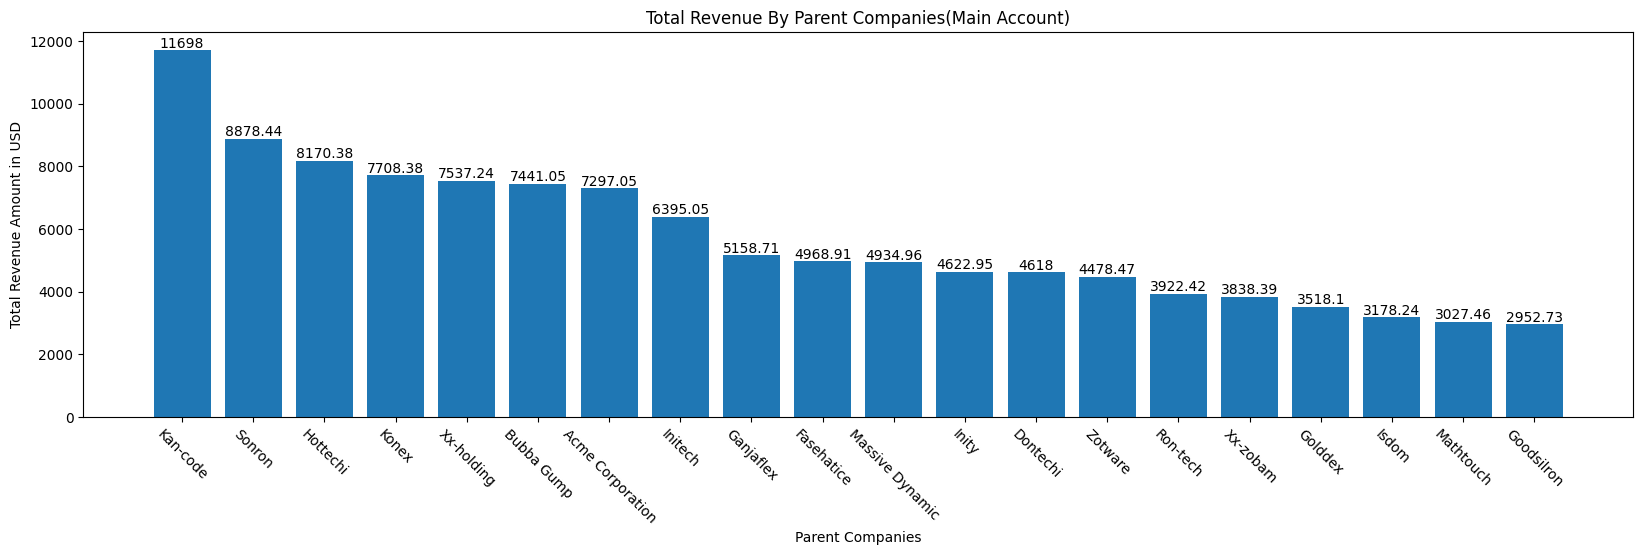

In [ ]:
#Total revenue by parent companies (main account)

revenue_by_account = acc_main.groupby('main_accn')['revenue_x'].sum().sort_values(ascending=False).reset_index()
print(f"\n***Top 10 Companies with most revenue share:\n\n{revenue_by_account.head(10)}")
print(f"\n***Companies with least revenue share:\n\n{revenue_by_account.tail(10)}")


plt.figure(figsize=(20,5))
top_10_acc_rev = revenue_by_account.head(20)
figure_ax2= plt.bar(top_10_acc_rev['main_accn'], top_10_acc_rev['revenue_x'])
plt.bar_label(figure_ax2)
plt.xticks(rotation=-45)
plt.title('Total Revenue By Parent Companies(Main Account)')
plt.xlabel('Parent Companies')
plt.ylabel('Total Revenue Amount in USD')
plt.show()

In [ ]:
#acc.info()

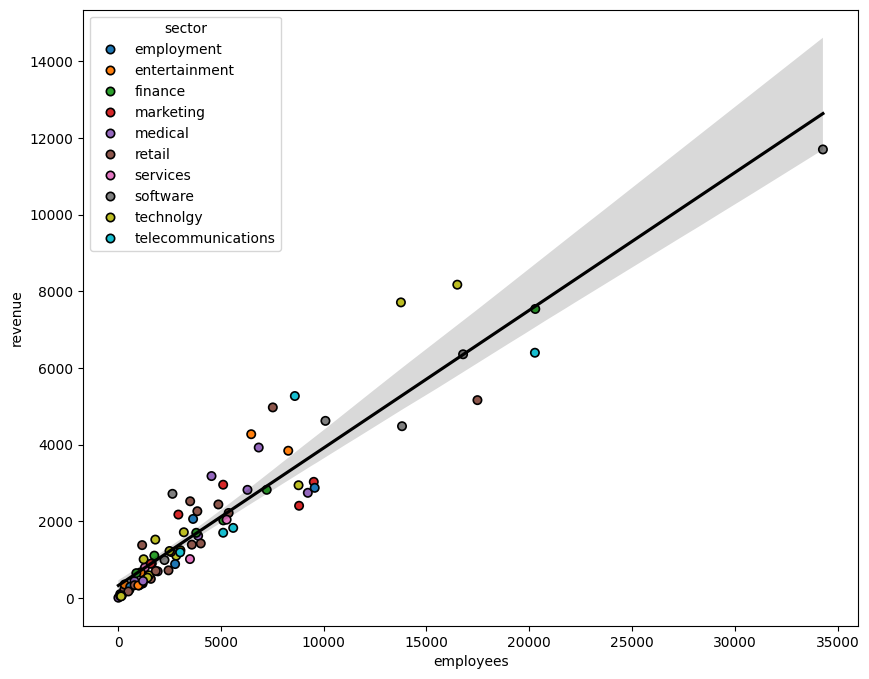



Correlation Cefficient between employees and revenue: 
[[1.         0.94608437]
 [0.94608437 1.        ]]


Coorelation between revenue and employees : 0.9460843747719687

p-value on hypothesis test: 2.1425602647004776e-42

 High correlation value >0.90 and p-value <0.05 observed. Thus we reject the null hypothesis, 
and accept the alternative, that there exists a positive correlation between employees and revenue.


In [ ]:
# Correlation test + hypothestsi testing
# Null hypothesis: there's no correlation between number of employees in a company (client) and total revenue/sales generated by the company

plt.figure(figsize=(10,8))
sns.scatterplot(x=acc['employees'], y=acc['revenue'], hue=acc['sector'], palette="tab10", edgecolor="black", linewidth=1.2)
sns.regplot(x=acc['employees'], y=acc['revenue'], scatter=False, color="black")
plt.show()
#Pearson Correlation Coefficient
print(f"\n\nCorrelation Cefficient between employees and revenue: \n{np.corrcoef(acc['employees'], acc['revenue'])}")

# Using Pearson's correlation test, assuming
# 1. Equal variable pairing, 2. Each variable is continuous, 3. No Outliers, 4. Linearity and homoscedastic
x= acc['employees']
y= acc['revenue']
print(f"\n\nCoorelation between revenue and employees : {scipy.stats.pearsonr(x,y)[0]}")
print(f"\np-value on hypothesis test: {scipy.stats.pearsonr(x,y)[1]}")
print("\n High correlation value >0.90 and p-value <0.05 observed. Thus we reject the null hypothesis, \nand accept the alternative, that there exists a positive correlation between employees and revenue.")


In [ ]:
# Based on company's year of establishment, comparing their sales/revenue generated.
## This will provide us with an idea if legacy companies (established), are generateing more revenue than the newly formed start-ups or ventures

#acc['year_established'].value_counts().sort_index(ascending=True)

rev_year = acc.groupby(['year_established'])['revenue'].sum().reset_index()
rev_year = rev_year.sort_values(by='revenue', ascending=False)
rev_year.head(10)

,year_established,revenue
2,1982,17108.49
13,1993,13695.56
17,1997,11385.50
14,1994,10757.08
16,1996,10109.06
15,1995,9490.94
8,1988,8702.79
1,1980,7708.38
10,1990,7489.74
12,1992,5959.29


Legacy companies (here, pre 1998) generate revenue 
above-avg revenue, in contrast to the newly established companies 
which generate lesser revenue and contribute to lower 
sales


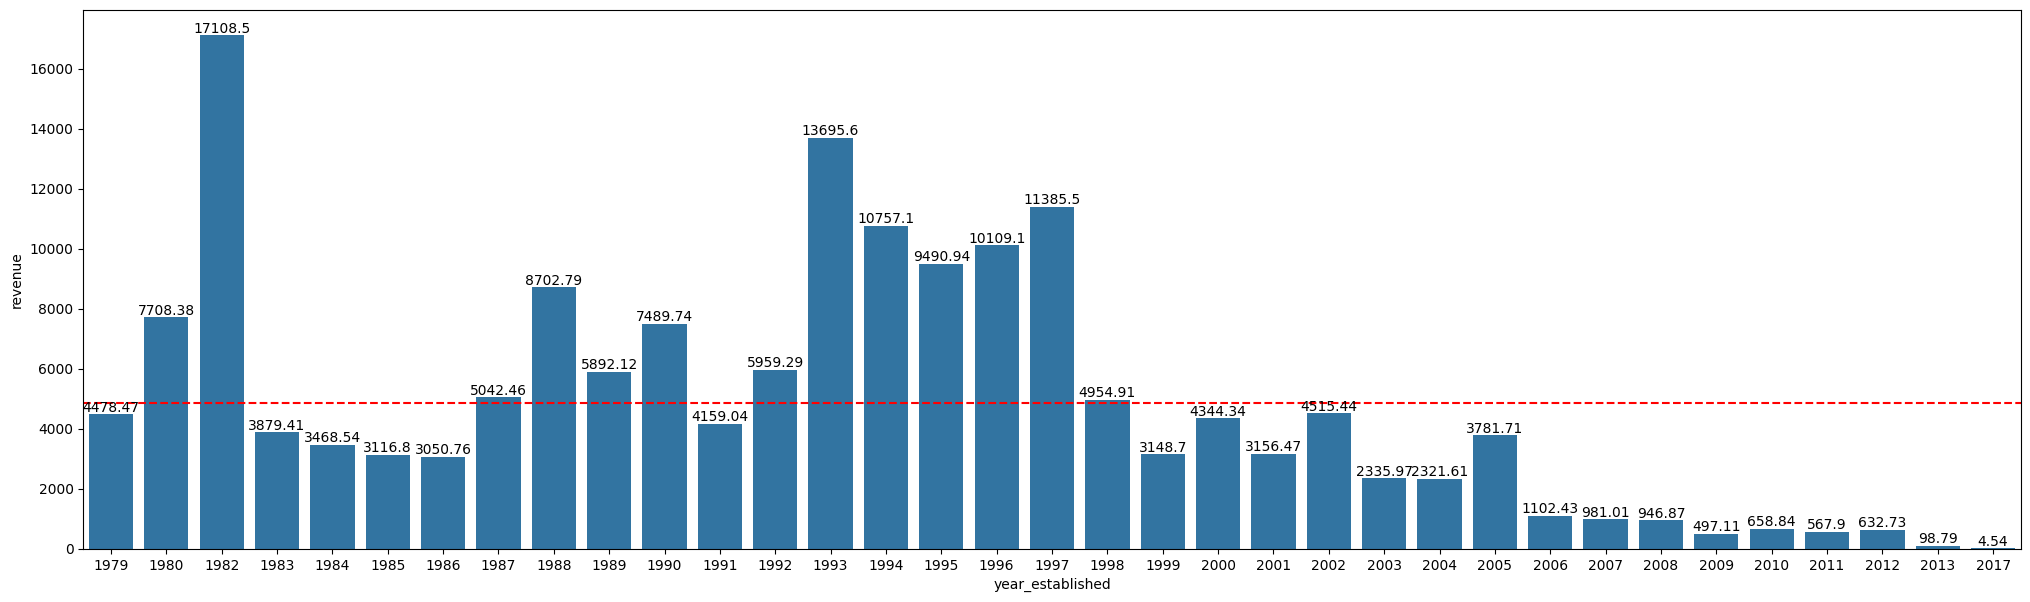

In [ ]:
plt.figure(figsize=(25,7))
avg_year_rev = rev_year['revenue'].mean()
ax_figue1 = sns.barplot(x='year_established', y='revenue', data= rev_year)
print("Legacy companies (here, pre 1998) generate revenue \nabove-avg revenue, in contrast to the newly established companies \nwhich generate lesser revenue and contribute to lower \nsales")
ax_figue1.bar_label(ax_figue1.containers[0])
plt.axhline(y=avg_year_rev, color='red', linestyle='--', label=avg_year_rev)

/tmp/ipython-input-3156329529.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = acc.pivot_table(index='year_established', columns='sector', values='revenue', aggfunc='sum', fill_value=0)


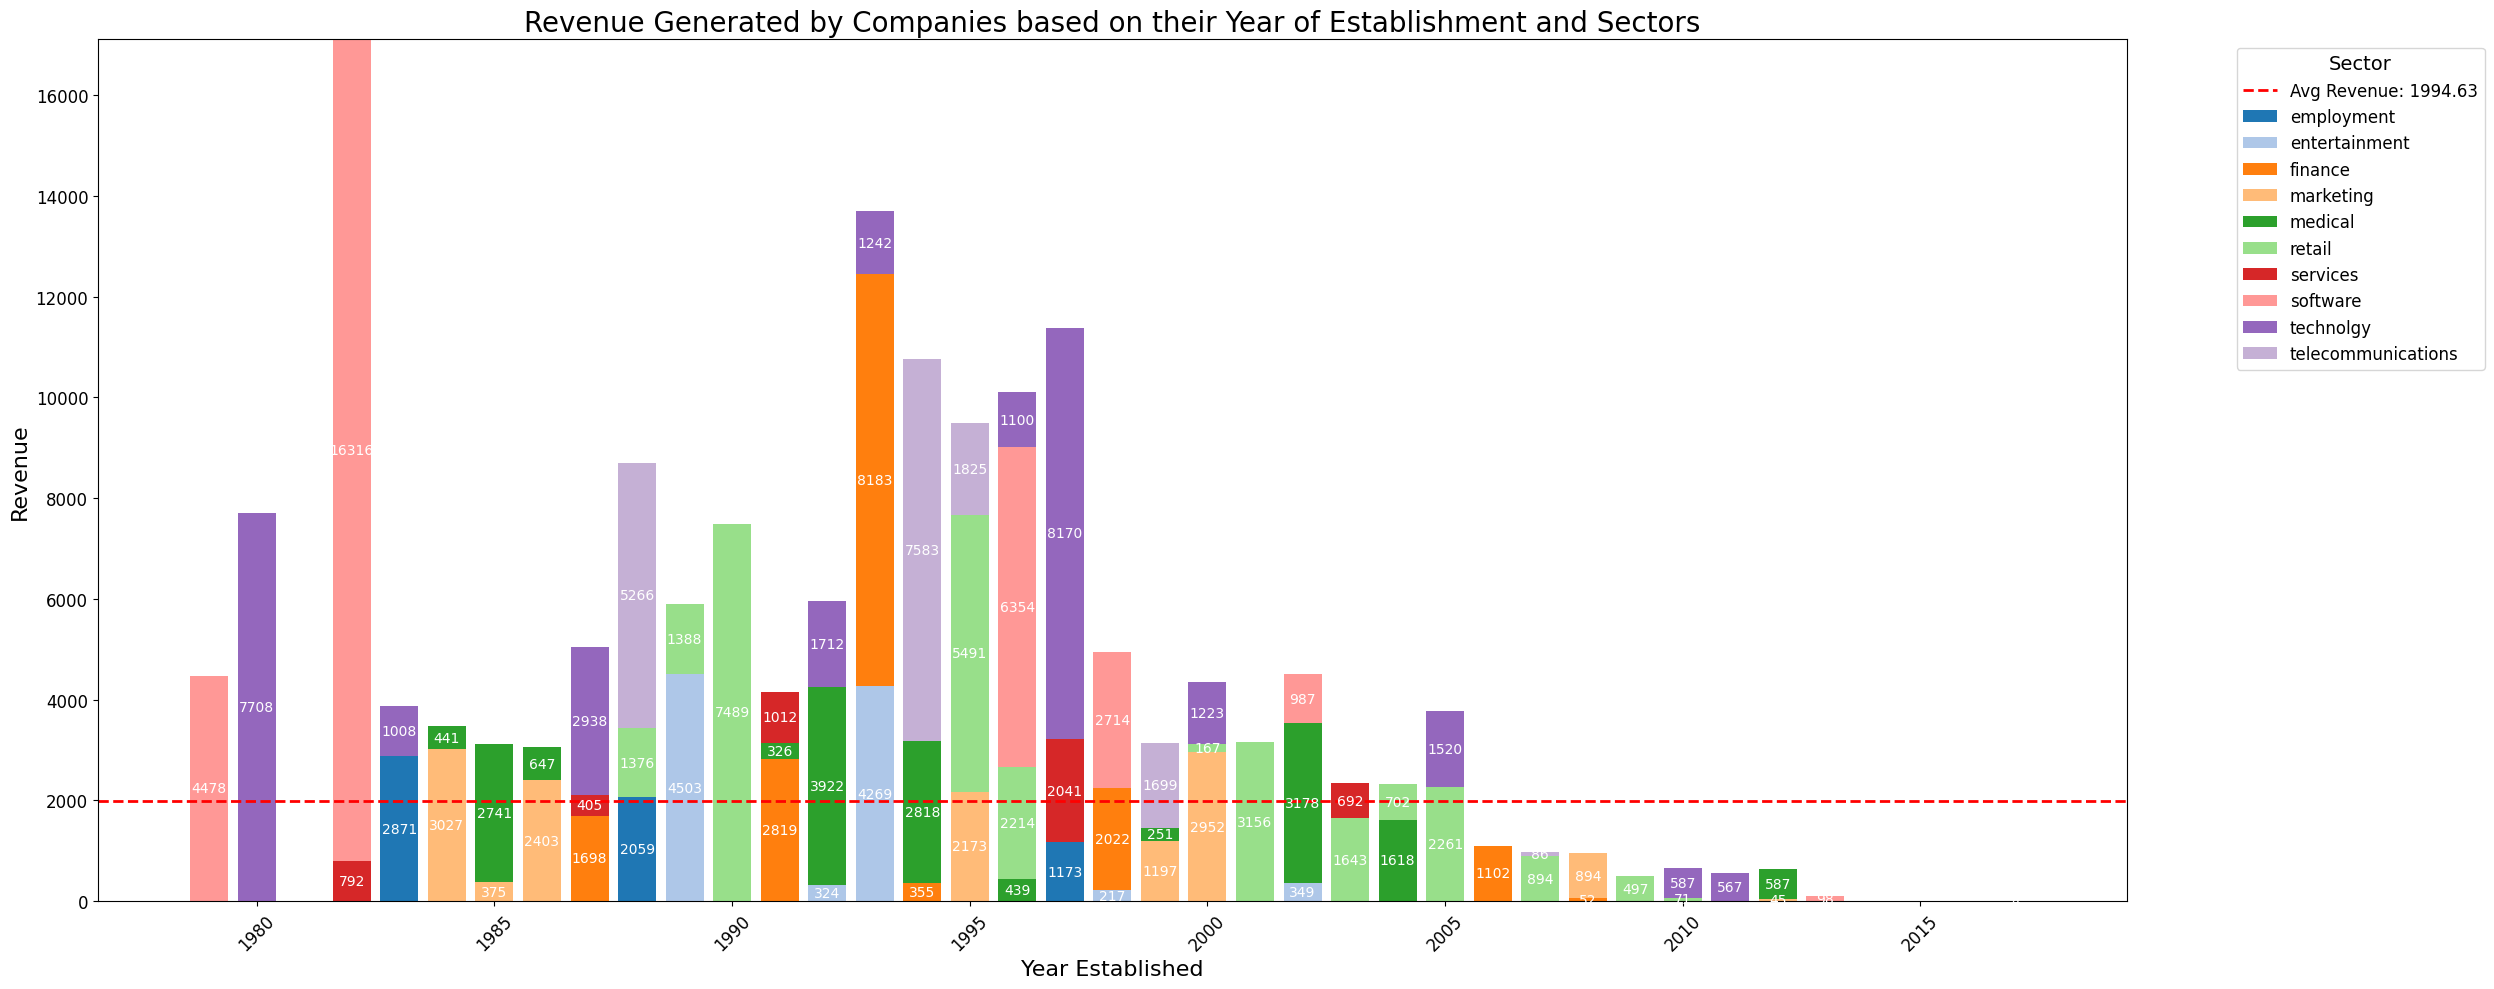

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Pivot data
pivot_df = acc.pivot_table(index='year_established', columns='sector', values='revenue', aggfunc='sum', fill_value=0)

fig, ax = plt.subplots(figsize=(25,10))

bottom = np.zeros(len(pivot_df))
colors = plt.cm.tab20.colors
sector_list = pivot_df.columns.tolist()

# Plot each sector individually and add labels
for i, sector in enumerate(sector_list):
    bars = ax.bar(pivot_df.index, pivot_df[sector], bottom=bottom, label=sector, color=colors[i % len(colors)])

    # Add labels inside each bar segment
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # avoid labeling zero-height segments
            ax.text(
                bar.get_x() + bar.get_width()/2,      # X position: center of the bar
                bar.get_y() + height/2,               # Y position: middle of the segment
                f'{int(height)}',                      # Label text
                ha='center',
                va='center',
                fontsize=10,
                color='white'                          # white text for contrast
            )
    bottom += pivot_df[sector].values  # update bottom for stacking

# Average revenue line
avg_year_rev = acc['revenue'].mean()
ax.axhline(y=avg_year_rev, color='red', linestyle='--', linewidth=2, label=f'Avg Revenue: {avg_year_rev:.2f}')

# Labels and title
ax.set_xlabel('Year Established', fontsize=16)
ax.set_ylabel('Revenue', fontsize=16)
ax.set_title('Revenue Generated by Companies based on their Year of Establishment and Sectors', fontsize=20)

# Legend
ax.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=14)

# Rotate x-axis labels
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

               sector  total_revenue  average_revenue
0            software       30950.45          4421.49
1           technolgy       27780.53          2315.04
2              retail       27355.76          1609.16
3             medical       16976.88          1414.74
4  telecommunications       16461.91          2743.65
5             finance       16233.34          2029.17
6           marketing       13070.38          1633.80
7       entertainment        9665.22          1610.87
8          employment        6104.64          1526.16
9            services        4944.69           988.94


Avg Revenue Overall = 2029.3



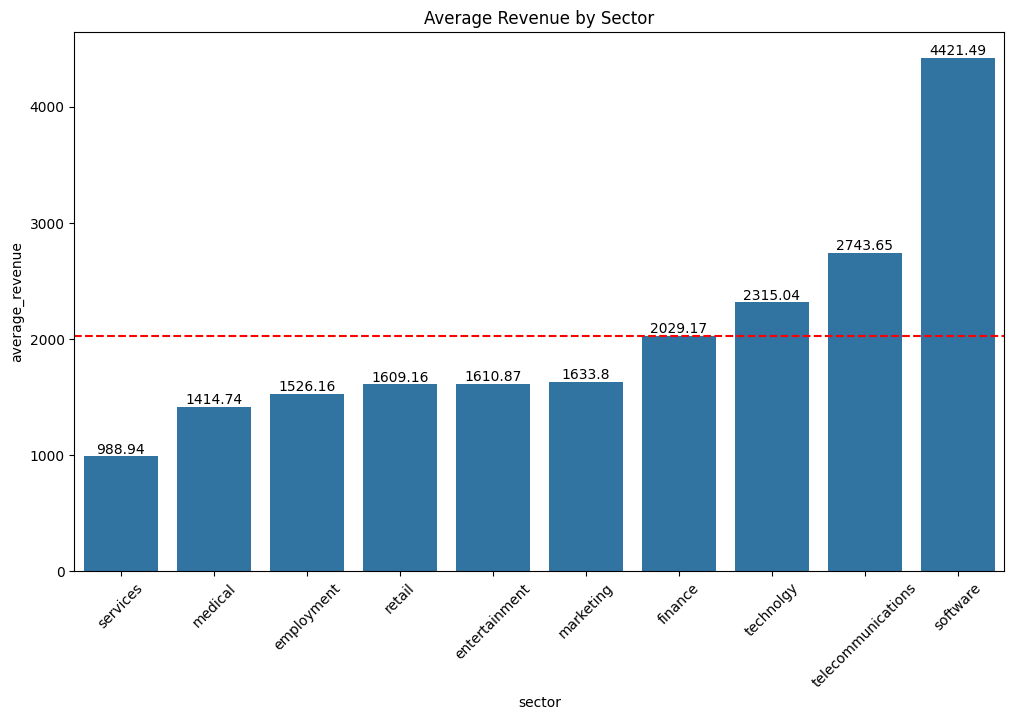

In [ ]:
# Average and Total Revenue Generated by Sectors

print(rev_by_sec)

#Average Revenue Generated by Sectors


#Adding an avg line
avg_rev_accn = rev_by_sec['average_revenue'].mean().round(2)
print(f"\n\nAvg Revenue Overall = {avg_rev_accn}\n")

#bar plot with avg line
plt.figure(figsize=(12,7))
ax = sns.barplot(
    data=rev_by_sec,
    x='sector',
    y='average_revenue',
    order=rev_by_sec.sort_values(by="average_revenue", ascending = True)['sector']
)
plt.title('Average Revenue by Sector')
ax.bar_label(ax.containers[0])
plt.axhline(y=avg_rev_accn, color='red', linestyle='--', label=avg_rev_accn)
plt.xticks(rotation=45)  # if sector names are long
plt.show()


In [ ]:
#View data
acc

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,Not a Subsidiary
1,Betasoloin,medical,1999,251.41,495,United States,Not a Subsidiary
2,Betatech,medical,1986,647.18,1185,Kenya,Not a Subsidiary
3,Bioholding,medical,2012,587.34,1356,Philipines,Not a Subsidiary
4,Bioplex,medical,1991,326.82,1016,United States,Not a Subsidiary
...,...,...,...,...,...,...,...
80,Zathunicon,retail,2010,71.12,144,United States,Not a Subsidiary
81,Zencorporation,technolgy,2011,40.79,142,China,Not a Subsidiary
82,Zoomit,entertainment,1992,324.19,978,United States,Not a Subsidiary
83,Zotware,software,1979,4478.47,13809,United States,Not a Subsidiary


In [ ]:
#total accounts for each country, the total revenue generate, and their market share
'''
result10 = acc.groupby('office_location')['account'].count().reset_index()
result10.columns = ['office_location', 'total_accounts']
result10.sort_values(by='total_accounts', ascending=False)
result10['total_revenue'] = acc.groupby('office_location')['revenue'].sum().reset_index()['revenue']
result10 = result10.sort_values(by='total_revenue', ascending= False)
result10['revenue_share'] = result10['total_revenue']/result10['total_revenue'].sum()
result10['revenue_share'] = result10['revenue_share'].round(2)
result10'''

"\nresult10 = acc.groupby('office_location')['account'].count().reset_index()\nresult10.columns = ['office_location', 'total_accounts']\nresult10.sort_values(by='total_accounts', ascending=False)\nresult10['total_revenue'] = acc.groupby('office_location')['revenue'].sum().reset_index()['revenue']\nresult10 = result10.sort_values(by='total_revenue', ascending= False)\nresult10['revenue_share'] = result10['total_revenue']/result10['total_revenue'].sum()\nresult10['revenue_share'] = result10['revenue_share'].round(2)\nresult10"

In [ ]:
#Total Accounts For Each Country, The Total Revenue Generate, And Their Market Share

result10 = acc.groupby('office_location')['account'].count().reset_index()
result10.columns = ['office_location', 'total_accounts']

total_revenue = acc.groupby('office_location')['revenue'].sum().reset_index()
total_revenue = total_revenue.rename(columns={'revenue':'total_revenue'})

result10 = pd.merge(result10, total_revenue, on='office_location')
result10['revenue_share'] = (result10['total_revenue'] / result10['total_revenue'].sum()).round(2)

result10 = result10.sort_values(by='total_revenue', ascending=False).reset_index(drop=True)
result10

,office_location,total_accounts,total_revenue,revenue_share
0,United States,71,142997.85,0.84
1,Korea,1,8170.38,0.05
2,Japan,1,5158.71,0.03
3,Jordan,1,3027.46,0.02
4,Panama,1,2938.67,0.02
5,Belgium,1,1376.80,0.01
6,Norway,1,1223.72,0.01
7,Germany,1,1012.72,0.01
8,Poland,1,894.37,0.01
9,Italy,1,894.33,0.01


In [ ]:
#Most recently created accounts, which market do they belong to, their office location, associating parent company, and the amount of total revenue generated

result20 = acc.groupby(['year_established', 'account', 'office_location', 'subsidiary_of']).agg({'revenue': 'sum'}).reset_index()
result20.columns = ['year_established', 'account', 'office_location','parent_company','total_revenue']
result20 = result20.sort_values(by='year_established', ascending=False)
result20 = result20.sort_values(['year_established', 'total_revenue'], ascending=[False, False])
result20

,year_established,account,office_location,parent_company,total_revenue
84,2017,Condax,United States,Not a Subsidiary,4.54
83,2013,Dalttechnology,United States,Bubba Gump,98.79
81,2012,Bioholding,Philipines,Not a Subsidiary,587.34
82,2012,Scottech,United States,Inity,45.39
79,2011,Iselectrics,United States,Acme Corporation,527.11
...,...,...,...,...,...
4,1982,Kan-code,United States,Not a Subsidiary,11698.03
2,1982,Dontechi,United States,Not a Subsidiary,4618.00
3,1982,Hatfan,United States,Not a Subsidiary,792.46
1,1980,Konex,United States,Not a Subsidiary,7708.38


In [ ]:
#Adding sector to the above table
result20 = acc.groupby(['year_established', 'account', 'office_location', 'subsidiary_of']) \
              .agg({'revenue':'sum'}) \
              .reset_index()
result20 = pd.merge(result20, acc[['account','sector']].drop_duplicates(), on='account', how='left')
result20.columns = ['year_established', 'account', 'office_location','parent_company','total_revenue','sector']
result20 = result20.sort_values(['year_established', 'total_revenue'], ascending=[False, False])
result20

,year_established,account,office_location,parent_company,total_revenue,sector
84,2017,Condax,United States,Not a Subsidiary,4.54,medical
83,2013,Dalttechnology,United States,Bubba Gump,98.79,software
81,2012,Bioholding,Philipines,Not a Subsidiary,587.34,medical
82,2012,Scottech,United States,Inity,45.39,marketing
79,2011,Iselectrics,United States,Acme Corporation,527.11,technolgy
...,...,...,...,...,...,...
4,1982,Kan-code,United States,Not a Subsidiary,11698.03,software
2,1982,Dontechi,United States,Not a Subsidiary,4618.00,software
3,1982,Hatfan,United States,Not a Subsidiary,792.46,services
1,1980,Konex,United States,Not a Subsidiary,7708.38,technolgy


In [ ]:
acc

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,Not a Subsidiary
1,Betasoloin,medical,1999,251.41,495,United States,Not a Subsidiary
2,Betatech,medical,1986,647.18,1185,Kenya,Not a Subsidiary
3,Bioholding,medical,2012,587.34,1356,Philipines,Not a Subsidiary
4,Bioplex,medical,1991,326.82,1016,United States,Not a Subsidiary
...,...,...,...,...,...,...,...
80,Zathunicon,retail,2010,71.12,144,United States,Not a Subsidiary
81,Zencorporation,technolgy,2011,40.79,142,China,Not a Subsidiary
82,Zoomit,entertainment,1992,324.19,978,United States,Not a Subsidiary
83,Zotware,software,1979,4478.47,13809,United States,Not a Subsidiary


#Pipeline Details EDA

In [ ]:
#View Table
sales_pipe

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,Won
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,Won
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,Won
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,Won
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,Won
...,...,...,...,...,...,...,...,...,...
8795,9MIWFW5J,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8796,6SLKZ8FI,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8797,LIB4KUZJ,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting
8798,18IUIUK0,Versie Hillebrand,MG Advanced,NaN,Prospecting,NaT,NaT,NaN,Prospecting


In [ ]:
sales_pipe['duration'] = (
    sales_pipe['close_date'] - sales_pipe['engage_date']
).dt.days
sales_pipe_win_lose = sales_pipe[sales_pipe['deal_stage'].isin(['Won', 'Lost'])]
sales_pipe_win_lose

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge,duration
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,Won,132.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,Won,137.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,Won,133.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,Won,135.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,Won,128.0
...,...,...,...,...,...,...,...,...,...,...
8295,2EBLR9N8,Lajuana Vencill,GTX Basic,Conecom,Won,2017-12-24,2017-12-26,622.0,Won,2.0
8296,VDGA4KXA,Violet Mclelland,GTX Plus Basic,Bluth Company,Won,2017-12-24,2017-12-30,1093.0,Won,6.0
8297,6WCNNK5J,Maureen Marcano,GTXPro,Hottechi,Won,2017-12-26,2017-12-29,4433.0,Won,3.0
8298,YJTQSZ9D,Gladys Colclough,GTX Plus Basic,Inity,Won,2017-12-27,2017-12-30,1052.0,Won,3.0


In [ ]:
from itertools import groupby
# Here, we'll be focusing on Won and Lost Deals
## Starting with total amount won (this will be the revenue generated) and lost (revenue loss)

d_sales_pipe_won_lost = sales_pipe[(sales_pipe['deal_stage']=='Won') | (sales_pipe['deal_stage']=='Lost')]
print(d_sales_pipe_won_lost.head(10))

d_sales_pipe_won_revenue = d_sales_pipe_won_lost[d_sales_pipe_won_lost['deal_stage']=='Won']['close_value'].sum()
print(f"\n\n*** Total Revenue Generated by Successful Sales in USD: {d_sales_pipe_won_revenue: ,.2f}\n")

d_sales_revenue_lost = d_sales_pipe_won_lost[d_sales_pipe_won_lost['deal_stage']=='Lost']
d_sales_revenue_lost

#Extracting only Won records
d_sales_pipe_won_recs = d_sales_pipe_won_lost[d_sales_pipe_won_lost['deal_stage']=='Won']
print(d_sales_pipe_won_recs)

   opportunity_id      sales_agent         product     account deal_stage engage_date close_date  close_value deal_satge  duration
0        1C1I7A6R      Moses Frase  GTX Plus Basic     Cancity        Won  2016-10-20 2017-03-01       1054.0        Won     132.0
1        Z063OYW0  Darcel Schlecht          GTXPro       Isdom        Won  2016-10-25 2017-03-11       4514.0        Won     137.0
2        EC4QE1BX  Darcel Schlecht      MG Special     Cancity        Won  2016-10-25 2017-03-07         50.0        Won     133.0
3        MV1LWRNH      Moses Frase       GTX Basic     Codehow        Won  2016-10-25 2017-03-09        588.0        Won     135.0
4        PE84CX4O        Zane Levy       GTX Basic      Hatfan        Won  2016-10-25 2017-03-02        517.0        Won     128.0
5        ZNBS69V1    Anna Snelling      MG Special    Ron-tech        Won  2016-10-29 2017-03-01         49.0        Won     123.0
6        9ME3374G   Vicki Laflamme      MG Special     J-Texon        Won  2016-10-

In [ ]:
d_sales_pipe_won_recs.loc[d_sales_pipe_won_recs['product'] == 'GTXPro', 'product'] = 'GTX Pro'
print(f"Adjusting the product name, GTXPro --> GTX Pro (as appears in product table): \n\n{d_sales_pipe_won_recs}\n\n\n")

d_sales_pipe_won_recs = pd.merge(d_sales_pipe_won_recs, prdts, on='product', how='left')
d_sales_pipe_won_recs['#units'] = (d_sales_pipe_won_recs['close_value']/d_sales_pipe_won_recs['sales_price']).round()
d_sales_pipe_won_recs

Adjusting the product name, GTXPro --> GTX Pro (as appears in product table): 

     opportunity_id       sales_agent         product        account deal_stage engage_date close_date  close_value deal_satge  duration
0          1C1I7A6R       Moses Frase  GTX Plus Basic        Cancity        Won  2016-10-20 2017-03-01       1054.0        Won     132.0
1          Z063OYW0   Darcel Schlecht         GTX Pro          Isdom        Won  2016-10-25 2017-03-11       4514.0        Won     137.0
2          EC4QE1BX   Darcel Schlecht      MG Special        Cancity        Won  2016-10-25 2017-03-07         50.0        Won     133.0
3          MV1LWRNH       Moses Frase       GTX Basic        Codehow        Won  2016-10-25 2017-03-09        588.0        Won     135.0
4          PE84CX4O         Zane Levy       GTX Basic         Hatfan        Won  2016-10-25 2017-03-02        517.0        Won     128.0
...             ...               ...             ...            ...        ...         ...       

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge,duration,series,sales_price,#units
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,Won,132.0,GTX,1096,1.0
1,Z063OYW0,Darcel Schlecht,GTX Pro,Isdom,Won,2016-10-25,2017-03-11,4514.0,Won,137.0,GTX,4821,1.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,Won,133.0,MG,55,1.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,Won,135.0,GTX,550,1.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,Won,128.0,GTX,550,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,2EBLR9N8,Lajuana Vencill,GTX Basic,Conecom,Won,2017-12-24,2017-12-26,622.0,Won,2.0,GTX,550,1.0
4234,VDGA4KXA,Violet Mclelland,GTX Plus Basic,Bluth Company,Won,2017-12-24,2017-12-30,1093.0,Won,6.0,GTX,1096,1.0
4235,6WCNNK5J,Maureen Marcano,GTX Pro,Hottechi,Won,2017-12-26,2017-12-29,4433.0,Won,3.0,GTX,4821,1.0
4236,YJTQSZ9D,Gladys Colclough,GTX Plus Basic,Inity,Won,2017-12-27,2017-12-30,1052.0,Won,3.0,GTX,1096,1.0


In [ ]:
#Checkin total number of units
print(f"\n*** Total units solds and the frequency of each unit sale:\n\n{d_sales_pipe_won_recs['#units'].value_counts().reset_index()}")

print("\n\n\n--->This tells us that the unit size of each sale was just 1 and not multiple units. \nHence, now we'll look at the discount provided or the marginal profit gained on each product sale\n\n\n")
d_sales_pipe_won_recs['margin'] = ((d_sales_pipe_won_recs['close_value'] - d_sales_pipe_won_recs['sales_price'])/d_sales_pipe_won_recs['sales_price']).round(2)
d_sales_pipe_won_recs['margin_label'] = np.where(d_sales_pipe_won_recs['margin'] > 0, 'Profit', 'Discounted')
print(f"{d_sales_pipe_won_recs.head(10)}\n\n\n")

s_sales_won_margin = d_sales_pipe_won_recs.groupby('product')['margin'].mean().round(2).reset_index()
print(f"The average of product's margin i.e. discount and profit is negligible.\n\n{s_sales_won_margin}")


*** Total units solds and the frequency of each unit sale:

   #units  count
0     1.0   4238



--->This tells us that the unit size of each sale was just 1 and not multiple units. 
Hence, now we'll look at the discount provided or the marginal profit gained on each product sale



  opportunity_id      sales_agent         product     account deal_stage engage_date close_date  close_value deal_satge  duration series  sales_price  #units  margin margin_label
0       1C1I7A6R      Moses Frase  GTX Plus Basic     Cancity        Won  2016-10-20 2017-03-01       1054.0        Won     132.0    GTX         1096     1.0   -0.04   Discounted
1       Z063OYW0  Darcel Schlecht         GTX Pro       Isdom        Won  2016-10-25 2017-03-11       4514.0        Won     137.0    GTX         4821     1.0   -0.06   Discounted
2       EC4QE1BX  Darcel Schlecht      MG Special     Cancity        Won  2016-10-25 2017-03-07         50.0        Won     133.0     MG           55     1.0   -0.09   Discounted

In [ ]:
#Since the lost value of the sale is not available, we'll begin with simple estimate by calculating the total loss
#by calculating the avg sales for each product and also using the face value of each product
#It is important to note that, not all sales are dealt in face value, but a margin of discount is provided
# Also, the margin can positive (selling price highre than the face value), or negative (discounted)

#Calculating, avg and median prices for all products

d_won_sales_median_prices = d_sales_pipe_won_recs.groupby('product')['close_value'].median().round(2).reset_index()
d_won_sales_median_prices = d_won_sales_median_prices.sort_values(by='close_value', ascending=False)
print(f"Median Prices of Each Product:\n{d_won_sales_median_prices}")
#d_won_sales_median_prices
d_won_sales_avg_prices = d_sales_pipe_won_recs.groupby('product')['close_value'].mean().round(2).reset_index()
print(f"\n\n\nAverage Prices of Each Product:\n{d_won_sales_avg_prices}\n\n\n")

won_sales_price_stats = pd.merge(d_won_sales_median_prices, d_won_sales_avg_prices, on='product', how='left')
won_sales_price_stats.columns = ['product', 'median_sell_price', 'avg_sell_price']

won_sales_price_stats['price_difference'] = won_sales_price_stats['median_sell_price'] - won_sales_price_stats['avg_sell_price']


Median Prices of Each Product:
          product  close_value
0         GTK 500      25897.0
3    GTX Plus Pro       5503.0
4         GTX Pro       4828.0
5     MG Advanced       3382.5
2  GTX Plus Basic       1083.0
1       GTX Basic        547.0
6      MG Special         55.0



Average Prices of Each Product:
          product  close_value
0         GTK 500     26707.47
1       GTX Basic       545.64
2  GTX Plus Basic      1080.05
3    GTX Plus Pro      5489.88
4         GTX Pro      4815.61
5     MG Advanced      3388.97
6      MG Special        55.19





In [ ]:
#Getting Products table to assign face value of each product and then use it to get the avg amount of units sold
print(f"\nProducts and their face value/sales price: \n\n{prdts}")
won_sales_price_stats2 = pd.merge(won_sales_price_stats, prdts, on='product', how='left')
won_sales_price_stats2


Products and their face value/sales price: 

          product series  sales_price
0       GTX Basic    GTX          550
1         GTX Pro    GTX         4821
2      MG Special     MG           55
3     MG Advanced     MG         3393
4    GTX Plus Pro    GTX         5482
5  GTX Plus Basic    GTX         1096
6         GTK 500    GTK        26768


,product,median_sell_price,avg_sell_price,price_difference,series,sales_price
0,GTK 500,25897.0,26707.47,-810.47,GTK,26768
1,GTX Plus Pro,5503.0,5489.88,13.12,GTX,5482
2,GTX Pro,4828.0,4815.61,12.39,GTX,4821
3,MG Advanced,3382.5,3388.97,-6.47,MG,3393
4,GTX Plus Basic,1083.0,1080.05,2.95,GTX,1096
5,GTX Basic,547.0,545.64,1.36,GTX,550
6,MG Special,55.0,55.19,-0.19,MG,55


In [ ]:
# Considering AVG/Mean price for best case scenario and Median price for worst case scenario.
# To calculate the total loss of potential revenue/sales pitch
## Before that, we need to get the total number of sales pitch/deals that were list for each product

d_sales_revenue_lost = d_sales_pipe_won_lost[d_sales_pipe_won_lost['deal_stage']=='Lost']
d_lost_sales_prdt_freq = d_sales_revenue_lost.groupby('product')['opportunity_id'].count().reset_index()
d_lost_sales_prdt_freq.loc[d_lost_sales_prdt_freq['product'] == 'GTXPro', 'product'] = 'GTX Pro'
print(f"\nTotal Opportunities Lost: \n\n{d_lost_sales_prdt_freq}\n\n\n")


#d_lost_estimate = pd.merge(won_sales_price_stats, d_lost_sales_prdt_freq, on='product', how='left')
#d_lost_estimate['total_loss_avg_est'] = (d_lost_estimate['avg_sell_price'] * d_lost_estimate['opportunity_id']).round(2)
#d_lost_estimate['total_loss_medn_est'] = (d_lost_estimate['median_sell_price'] * d_lost_estimate['opportunity_id']).round(2)

d_lost_revenue = pd.merge(won_sales_price_stats2, d_lost_sales_prdt_freq, on='product', how='left')
print(f"The total margin of product sale is negligible, hence we are not considering the effect of the margins on the total loss: \n\n{d_lost_revenue}")


Total Opportunities Lost: 

          product  opportunity_id
0         GTK 500              10
1       GTX Basic             521
2  GTX Plus Basic             398
3    GTX Plus Pro             266
4         GTX Pro             418
5     MG Advanced             430
6      MG Special             430



The total margin of product sale is negligible, hence we are not considering the effect of the margins on the total loss: 

          product  median_sell_price  avg_sell_price  price_difference series  sales_price  opportunity_id
0         GTK 500            25897.0        26707.47           -810.47    GTK        26768              10
1    GTX Plus Pro             5503.0         5489.88             13.12    GTX         5482             266
2         GTX Pro             4828.0         4815.61             12.39    GTX         4821             418
3     MG Advanced             3382.5         3388.97             -6.47     MG         3393             430
4  GTX Plus Basic             1083.0 

In [ ]:
#Total revenue loss by products

d_total_lost_revenue = d_lost_revenue.copy()
d_total_lost_revenue['loss_avg_est'] = (d_total_lost_revenue['avg_sell_price'] * d_total_lost_revenue['opportunity_id'])
d_total_lost_revenue['d_face_value_loss_est'] = (d_total_lost_revenue['sales_price'] * d_total_lost_revenue['opportunity_id'])
print(d_total_lost_revenue)
print(f"\n\nTotal Avg Estimated Loss:{d_total_lost_revenue['loss_avg_est'].sum(): ,.2f}\n\n")
print(f"Total Face Value Estimated Loss:{d_total_lost_revenue['d_face_value_loss_est'].sum(): ,.2f}\n\n")

          product  median_sell_price  avg_sell_price  price_difference series  sales_price  opportunity_id  loss_avg_est  d_face_value_loss_est
0         GTK 500            25897.0        26707.47           -810.47    GTK        26768              10     267074.70                 267680
1    GTX Plus Pro             5503.0         5489.88             13.12    GTX         5482             266    1460308.08                1458212
2         GTX Pro             4828.0         4815.61             12.39    GTX         4821             418    2012924.98                2015178
3     MG Advanced             3382.5         3388.97             -6.47     MG         3393             430    1457257.10                1458990
4  GTX Plus Basic             1083.0         1080.05              2.95    GTX         1096             398     429859.90                 436208
5       GTX Basic              547.0          545.64              1.36    GTX          550             521     284278.44                

In [ ]:
#Avg duration spent on the sales pitch/deal
d_sales_pipe_won_lost['engaged_duration'] = (
    d_sales_pipe_won_lost['close_date'] - d_sales_pipe_won_lost['engage_date']
).dt.days

d_sales_pipe_won_lost

/tmp/ipython-input-816373474.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d_sales_pipe_won_lost['engaged_duration'] = (


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge,duration,engaged_duration
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,Won,132.0,132
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,Won,137.0,137
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,Won,133.0,133
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,Won,135.0,135
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,Won,128.0,128
...,...,...,...,...,...,...,...,...,...,...,...
8295,2EBLR9N8,Lajuana Vencill,GTX Basic,Conecom,Won,2017-12-24,2017-12-26,622.0,Won,2.0,2
8296,VDGA4KXA,Violet Mclelland,GTX Plus Basic,Bluth Company,Won,2017-12-24,2017-12-30,1093.0,Won,6.0,6
8297,6WCNNK5J,Maureen Marcano,GTXPro,Hottechi,Won,2017-12-26,2017-12-29,4433.0,Won,3.0,3
8298,YJTQSZ9D,Gladys Colclough,GTX Plus Basic,Inity,Won,2017-12-27,2017-12-30,1052.0,Won,3.0,3


In [ ]:
#Avg duration engaged fow successful sales by products
d_won_avg_time = d_sales_pipe_won_lost[d_sales_pipe_won_lost['deal_stage']=="Won"]
d_won_avg_time_prdts = d_won_avg_time.groupby('product')['engaged_duration'].mean().round(2).reset_index()
print(f"\n\nAvg duration in days for successful deal:\n\n{d_won_avg_time_prdts}\n\n\n\n")

d_lost_avg_time = d_sales_pipe_won_lost[d_sales_pipe_won_lost['deal_stage']=="Lost"]
d_lost_avg_time_prdts = d_lost_avg_time.groupby('product')['engaged_duration'].mean().round(2).reset_index()
print(f"Avg duration in days for lost deal:\n\n{d_lost_avg_time_prdts}")



Avg duration in days for successful deal:

          product  engaged_duration
0         GTK 500             64.07
1       GTX Basic             54.77
2  GTX Plus Basic             51.76
3    GTX Plus Pro             51.73
4          GTXPro             48.33
5     MG Advanced             51.78
6      MG Special             51.34




Avg duration in days for lost deal:

          product  engaged_duration
0         GTK 500             38.20
1       GTX Basic             41.37
2  GTX Plus Basic             45.56
3    GTX Plus Pro             35.90
4          GTXPro             41.22
5     MG Advanced             40.04
6      MG Special             43.05


###Assessing the statistical significance of duration engaged for a suuccessful outcome of the deals/sales.

#####Using Point-Biserial Coorelation test for 'Categorical' and 'Continuous' variable

In [ ]:
#Statistical test
#First, Converting Deal Stages in to 1s/0s

d_sales_pipe_won_lost['deal_stage_num'] = d_sales_pipe_won_lost['deal_stage'].apply(lambda x: 1 if x == 'Won' else 0)
print(f"{d_sales_pipe_won_lost.head(5)}\n\n")

from scipy import stats

print(f"Point Biserial result:\n{stats.pointbiserialr(d_sales_pipe_won_lost['deal_stage_num'], d_sales_pipe_won_lost['engaged_duration'])}")

np.corrcoef(d_sales_pipe_won_lost['deal_stage_num'], d_sales_pipe_won_lost['engaged_duration'])

  opportunity_id      sales_agent         product  account deal_stage engage_date close_date  close_value deal_satge  duration  engaged_duration  deal_stage_num
0       1C1I7A6R      Moses Frase  GTX Plus Basic  Cancity        Won  2016-10-20 2017-03-01       1054.0        Won     132.0               132               1
1       Z063OYW0  Darcel Schlecht          GTXPro    Isdom        Won  2016-10-25 2017-03-11       4514.0        Won     137.0               137               1
2       EC4QE1BX  Darcel Schlecht      MG Special  Cancity        Won  2016-10-25 2017-03-07         50.0        Won     133.0               133               1
3       MV1LWRNH      Moses Frase       GTX Basic  Codehow        Won  2016-10-25 2017-03-09        588.0        Won     135.0               135               1
4       PE84CX4O        Zane Levy       GTX Basic   Hatfan        Won  2016-10-25 2017-03-02        517.0        Won     128.0               128               1


Point Biserial result:
Significa

/tmp/ipython-input-1138674198.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d_sales_pipe_won_lost['deal_stage_num'] = d_sales_pipe_won_lost['deal_stage'].apply(lambda x: 1 if x == 'Won' else 0)


array([[1.        , 0.12105942],
       [0.12105942, 1.        ]])

#####We can conclude from the above statstical test, we are looking at a weaker positive correlation between sales outcome and the duration invested for the sale.
#####In addition to this, we have identified statstical evidence through Point-Biserial test, with the p-value being <0.05, we can reject the null hypothesis and accept the alternate hypothesis.

#####Null Hypothesis: There's no significant difference in the invested duration for the deal's outcome. The time spent does not affect the outcome --- (Rejected)

#####Alternative hypothesis: The duration invested in the deal stages affects the outcome --- (Accepted)

#Sales Person Performance Analysis

One of the essential aspects of performance analysis is sales metrics. These act as the “pulse” of any business, providing insights into what is happening within the company from a sales perspective. Unlike KPIs, which measure progress toward business goals, sales metrics focus on operational performance and open up possibilities for diagnosis. To ensure our analysis is thorough and aligned with general business trends, I am referencing an article by[ Oracle NetSuite](https://www.netsuite.com/portal/resource/articles/accounting/sales-metrics.shtml) that encapsulates key sales metrics and the insights they provide.

Outlining metrics:


1.   Average Revenue Per User/Account
2.   Win Rate
3.   Conversion Rate
4.   Average Sales Cycle Legth
5.   Average Deal Size
6.   Average Profit Margin
7.   Deal Slip Rate - (Later in the analysis)
8.   Lead Scoring
9.   Winning Streaks and Probabilities - (alternative addition)
10.  Quarterly contribution - (alternative addition)



In [ ]:
#gathering all required datasets for analysis
sales_pipe
#Setting up dataset for won and lost sales records
sales_pipe_wl = sales_pipe[sales_pipe['deal_stage'].isin(['Won', 'Lost'])]
sales_pipe_wl

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge,duration
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,Won,132.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,Won,137.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,Won,133.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,Won,135.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,Won,128.0
...,...,...,...,...,...,...,...,...,...,...
8295,2EBLR9N8,Lajuana Vencill,GTX Basic,Conecom,Won,2017-12-24,2017-12-26,622.0,Won,2.0
8296,VDGA4KXA,Violet Mclelland,GTX Plus Basic,Bluth Company,Won,2017-12-24,2017-12-30,1093.0,Won,6.0
8297,6WCNNK5J,Maureen Marcano,GTXPro,Hottechi,Won,2017-12-26,2017-12-29,4433.0,Won,3.0
8298,YJTQSZ9D,Gladys Colclough,GTX Plus Basic,Inity,Won,2017-12-27,2017-12-30,1052.0,Won,3.0


In [ ]:
#Getting accounts dataset
acc

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,Not a Subsidiary
1,Betasoloin,medical,1999,251.41,495,United States,Not a Subsidiary
2,Betatech,medical,1986,647.18,1185,Kenya,Not a Subsidiary
3,Bioholding,medical,2012,587.34,1356,Philipines,Not a Subsidiary
4,Bioplex,medical,1991,326.82,1016,United States,Not a Subsidiary
...,...,...,...,...,...,...,...
80,Zathunicon,retail,2010,71.12,144,United States,Not a Subsidiary
81,Zencorporation,technolgy,2011,40.79,142,China,Not a Subsidiary
82,Zoomit,entertainment,1992,324.19,978,United States,Not a Subsidiary
83,Zotware,software,1979,4478.47,13809,United States,Not a Subsidiary


In [ ]:
#Getting sales team dataset
sales_team

,sales_agent,manager,regional_office
0,Anna Snelling,Dustin Brinkmann,Central
1,Cecily Lampkin,Dustin Brinkmann,Central
2,Versie Hillebrand,Dustin Brinkmann,Central
3,Lajuana Vencill,Dustin Brinkmann,Central
4,Moses Frase,Dustin Brinkmann,Central
5,Jonathan Berthelot,Melvin Marxen,Central
6,Marty Freudenburg,Melvin Marxen,Central
7,Gladys Colclough,Melvin Marxen,Central
8,Niesha Huffines,Melvin Marxen,Central
9,Darcel Schlecht,Melvin Marxen,Central


In [ ]:
#merging datasets
merge_1 = pd.merge(sales_pipe_wl, acc, left_on='account', right_on='account', how='left')
merge_2 = pd.merge(merge_1, sales_team, left_on='sales_agent', right_on='sales_agent')
perf_data = merge_2.copy()
perf_data

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,deal_satge,duration,sector,year_established,revenue,employees,office_location,subsidiary_of,manager,regional_office
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,Won,132.0,retail,2001,718.62,2448,United States,Not a Subsidiary,Dustin Brinkmann,Central
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,Won,137.0,medical,2002,3178.24,4540,United States,Not a Subsidiary,Melvin Marxen,Central
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,Won,133.0,retail,2001,718.62,2448,United States,Not a Subsidiary,Melvin Marxen,Central
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,Won,135.0,software,1998,2714.90,2641,United States,Acme Corporation,Dustin Brinkmann,Central
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,Won,128.0,services,1982,792.46,1299,United States,Not a Subsidiary,Summer Sewald,West
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6706,2EBLR9N8,Lajuana Vencill,GTX Basic,Conecom,Won,2017-12-24,2017-12-26,622.0,Won,2.0,technolgy,2005,1520.66,1806,United States,Not a Subsidiary,Dustin Brinkmann,Central
6707,VDGA4KXA,Violet Mclelland,GTX Plus Basic,Bluth Company,Won,2017-12-24,2017-12-30,1093.0,Won,6.0,technolgy,1993,1242.32,3027,United States,Acme Corporation,Cara Losch,East
6708,6WCNNK5J,Maureen Marcano,GTXPro,Hottechi,Won,2017-12-26,2017-12-29,4433.0,Won,3.0,technolgy,1997,8170.38,16499,Korea,Not a Subsidiary,Summer Sewald,West
6709,YJTQSZ9D,Gladys Colclough,GTX Plus Basic,Inity,Won,2017-12-27,2017-12-30,1052.0,Won,3.0,marketing,1986,2403.58,8801,United States,Not a Subsidiary,Melvin Marxen,Central


In [ ]:
from matplotlib._api import define_aliases
#Total unique accounts for all won deals
win_acc = perf_data[perf_data['deal_stage']=='Won']['account'].value_counts().reset_index()
print(f"\n\n***** Accounts with successful sales records:\n\n {win_acc}\n\n\n")


win_acc_nums = perf_data[perf_data['deal_stage']=='Won']['account'].nunique()
print(f"***** Number of unqiue companies with successful sales records: {win_acc_nums}\n\n\n")


#Total revenue generated from won deals

rev_gen = perf_data[perf_data['deal_stage']=='Won']['close_value'].sum()
print(f"***** Total revenue generated in USD: {rev_gen: ,.2f}\n\n\n")

avg_rev_acc = rev_gen/win_acc_nums
print(f"***** Average revenue per account in USD: {avg_rev_acc: ,.2f}\n\n\n")



***** Accounts with successful sales records:

                   account  count
0                Kan-code    115
1                Hottechi    111
2                   Konex    108
3                  Condax    105
4                Rangreen     75
..                    ...    ...
80               Opentech     30
81  The New York Inquirer     28
82          Bluth Company     28
83            Iselectrics     25
84                 Sumace     23

[85 rows x 2 columns]



***** Number of unqiue companies with successful sales records: 85



***** Total revenue generated in USD:  10,005,534.00



***** Average revenue per account in USD:  117,712.16





Here, we will be calculating KPIs based on industrial standards to gather insights on every sales person's performance.
To support my analysis with a credible source and understanding, I am referring to [this article by Salesforce](https://www.salesforce.com/sales/performance-management/sales-kpis/), providing me with a baseline understanding of performance analysis.